In [4]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datasets and model selection
from sklearn.datasets import make_moons, load_breast_cancer
from sklearn.model_selection import train_test_split

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
)

# Evaluation and visualisation
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.inspection import DecisionBoundaryDisplay

# Keep the random seed fixed so the results are reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [5]:
def add_label_noise(y, noise_fraction=0.0, random_state=42):
    """
    Flip a fraction of binary labels.

    This is useful for testing whether a method is robust when some of the
    training labels are wrong. That matters here because boosting often pays
    extra attention to misclassified points.
    """
    rng = np.random.default_rng(random_state)
    y_noisy = y.copy()

    n_samples = len(y)
    n_flip = int(noise_fraction * n_samples)

    if n_flip == 0:
        return y_noisy

    flip_idx = rng.choice(n_samples, size=n_flip, replace=False)
    classes = np.unique(y)

    if len(classes) != 2:
        raise ValueError("This function currently expects a binary classification problem.")

    class_map = {classes[0]: classes[1], classes[1]: classes[0]}
    y_noisy[flip_idx] = np.vectorize(class_map.get)(y_noisy[flip_idx])

    return y_noisy


def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Fit a model and return a small set of training and test metrics.

    I keep both training and test scores because the gap between them helps
    show whether a model is simply fitting harder or actually generalising better.
    """
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    return {
        "train_accuracy": accuracy_score(y_train, y_train_pred),
        "test_accuracy": accuracy_score(y_test, y_test_pred),
        "train_f1": f1_score(y_train, y_train_pred),
        "test_f1": f1_score(y_test, y_test_pred),
    }


def make_models(n_estimators=50):
    """
    Build the models used throughout the comparison.

    The single tree acts as a baseline. Bagging and random forest represent
    averaging-based ensembles, while AdaBoost and Gradient Boosting represent
    sequential error-correcting ensembles.
    """
    weak_tree = DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE)

    models = {
        "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
        "Bagging": BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
            n_estimators=n_estimators,
            random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
        "AdaBoost": AdaBoostClassifier(
            estimator=weak_tree,
            n_estimators=n_estimators,
            random_state=RANDOM_STATE,
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=n_estimators,
            max_depth=2,
            random_state=RANDOM_STATE,
        ),
    }

    return models

In [6]:
# I start with make_moons because it is simple enough to visualise clearly,
# but still nonlinear enough to show meaningful differences in decision boundaries.
X_moons, y_moons = make_moons(
    n_samples=600,
    noise=0.25,
    random_state=RANDOM_STATE
)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons,
    y_moons,
    test_size=0.3,
    stratify=y_moons,
    random_state=RANDOM_STATE
)

print(f"Training samples: {X_train_m.shape[0]}")
print(f"Test samples: {X_test_m.shape[0]}")

Training samples: 420
Test samples: 180


In [7]:
# This first comparison gives a quick baseline before moving to deeper analysis.
models = make_models(n_estimators=50)

results = []
for name, model in models.items():
    metrics = evaluate_model(model, X_train_m, X_test_m, y_train_m, y_test_m)
    metrics["model"] = name
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values("test_accuracy", ascending=False)
results_df

,train_accuracy,test_accuracy,train_f1,test_f1,model
3,0.957143,0.922222,0.956522,0.922222,AdaBoost
0,0.919048,0.905556,0.918660,0.908108,Decision Tree
1,0.919048,0.905556,0.918660,0.908108,Bagging
4,0.923810,0.905556,0.923810,0.908108,Gradient Boosting
2,0.921429,0.894444,0.921986,0.898396,Random Forest


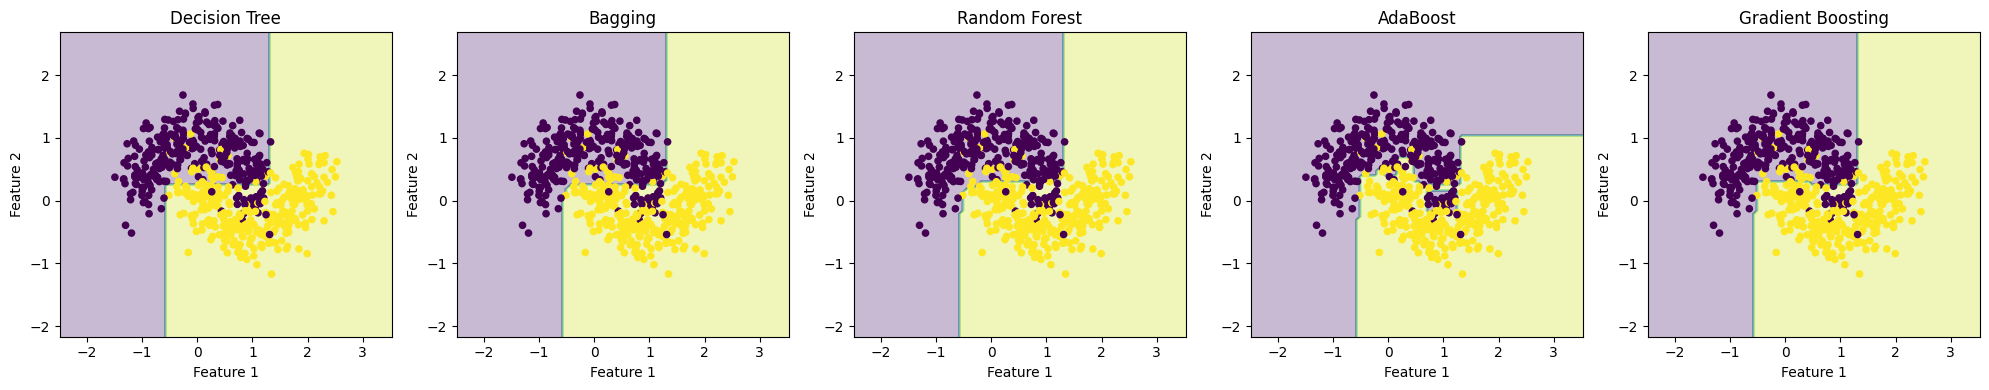

In [8]:
# Decision boundaries are one of the most useful teaching visuals in this project.
# They make it easier to see how bagging stabilises a tree, while boosting adapts
# more directly to difficult regions of the feature space.
fig, axes = plt.subplots(1, len(models), figsize=(20, 4))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train_m, y_train_m)

    DecisionBoundaryDisplay.from_estimator(
        model,
        X_moons,
        response_method="predict",
        alpha=0.3,
        ax=ax
    )

    ax.scatter(
        X_moons[:, 0],
        X_moons[:, 1],
        c=y_moons,
        s=20
    )
    ax.set_title(name)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

In [9]:
# Here I vary the number of estimators to see how each ensemble improves as it grows.
# This is more informative than comparing just one fixed model size.
estimator_values = [1, 5, 10, 25, 50, 100, 200]
rows = []

for n in estimator_values:
    current_models = {
        "Bagging": BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
            n_estimators=n,
            random_state=RANDOM_STATE,
        ),
        "Random Forest": RandomForestClassifier(
            n_estimators=n,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
        "AdaBoost": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
            n_estimators=n,
            random_state=RANDOM_STATE,
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=n,
            max_depth=2,
            random_state=RANDOM_STATE,
        ),
    }

    for name, model in current_models.items():
        metrics = evaluate_model(model, X_train_m, X_test_m, y_train_m, y_test_m)
        rows.append({
            "n_estimators": n,
            "model": name,
            "train_accuracy": metrics["train_accuracy"],
            "test_accuracy": metrics["test_accuracy"],
            "train_f1": metrics["train_f1"],
            "test_f1": metrics["test_f1"],
        })

estimator_df = pd.DataFrame(rows)
estimator_df.head()

,n_estimators,model,train_accuracy,test_accuracy,train_f1,test_f1
0,1,Bagging,0.909524,0.894444,0.910377,0.898396
1,1,Random Forest,0.883333,0.888889,0.883610,0.892473
2,1,AdaBoost,0.919048,0.905556,0.918660,0.908108
3,1,Gradient Boosting,0.919048,0.905556,0.918660,0.908108
4,5,Bagging,0.914286,0.900000,0.914286,0.903226


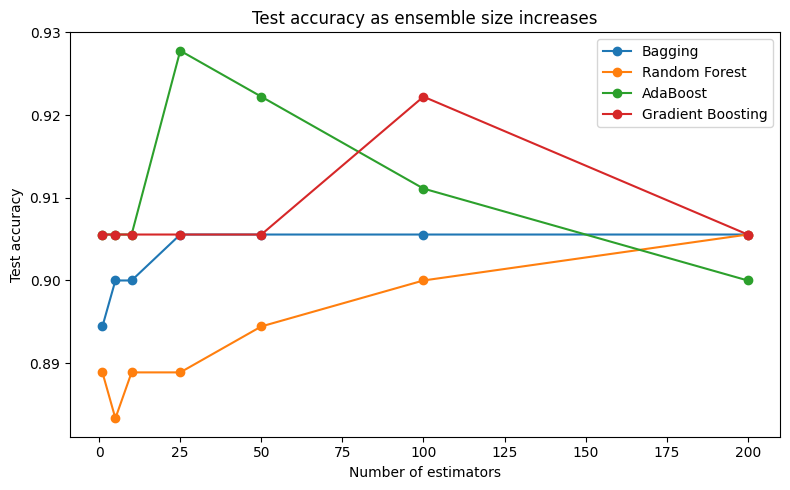

In [10]:
# I use markers as well as lines so the plot stays readable even in greyscale
# or for readers with colour-vision differences.
plt.figure(figsize=(8, 5))

for model_name in estimator_df["model"].unique():
    subset = estimator_df[estimator_df["model"] == model_name]
    plt.plot(
        subset["n_estimators"],
        subset["test_accuracy"],
        marker="o",
        label=model_name
    )

plt.xlabel("Number of estimators")
plt.ylabel("Test accuracy")
plt.title("Test accuracy as ensemble size increases")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# This is the key experiment for the main tutorial question.
# If boosting keeps focusing on mistakes, it may also pay too much attention
# to labels that are simply wrong. Bagging is often more stable in that setting.
noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30]
noise_rows = []

for noise in noise_levels:
    y_train_noisy = add_label_noise(
        y_train_m,
        noise_fraction=noise,
        random_state=RANDOM_STATE
    )

    noisy_models = {
        "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
        "Random Forest": RandomForestClassifier(
            n_estimators=100,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
        "AdaBoost": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
            n_estimators=100,
            random_state=RANDOM_STATE,
        ),
        "Gradient Boosting": GradientBoostingClassifier(
            n_estimators=100,
            max_depth=2,
            random_state=RANDOM_STATE,
        ),
    }

    for name, model in noisy_models.items():
        model.fit(X_train_m, y_train_noisy)
        y_test_pred = model.predict(X_test_m)

        noise_rows.append({
            "noise_fraction": noise,
            "model": name,
            "test_accuracy": accuracy_score(y_test_m, y_test_pred),
            "test_f1": f1_score(y_test_m, y_test_pred),
        })

noise_df = pd.DataFrame(noise_rows)
noise_df.head()

,noise_fraction,model,test_accuracy,test_f1
0,0.00,Decision Tree,0.905556,0.908108
1,0.00,Random Forest,0.900000,0.903226
2,0.00,AdaBoost,0.911111,0.911111
3,0.00,Gradient Boosting,0.922222,0.922222
4,0.05,Decision Tree,0.900000,0.901099


In [12]:
# A real dataset makes the tutorial feel less like a toy demonstration.
# I use Breast Cancer Wisconsin because it is clean, standard, and easy to reproduce.
data = load_breast_cancer()
X_real = data.data
y_real = data.target

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_real,
    y_real,
    test_size=0.3,
    stratify=y_real,
    random_state=RANDOM_STATE
)

real_models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=3,
        random_state=RANDOM_STATE,
    ),
    "AdaBoost": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE),
        n_estimators=100,
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=2,
        random_state=RANDOM_STATE,
    ),
}

real_results = []
for name, model in real_models.items():
    metrics = evaluate_model(model, X_train_r, X_test_r, y_train_r, y_test_r)
    metrics["model"] = name
    real_results.append(metrics)

real_results_df = pd.DataFrame(real_results).sort_values("test_accuracy", ascending=False)
real_results_df

,train_accuracy,test_accuracy,train_f1,test_f1,model
2,1.000000,0.976608,1.000000,0.981651,AdaBoost
3,1.000000,0.947368,1.000000,0.958525,Gradient Boosting
1,0.982412,0.935673,0.986139,0.948837,Random Forest
0,0.979899,0.923977,0.984190,0.940092,Decision Tree


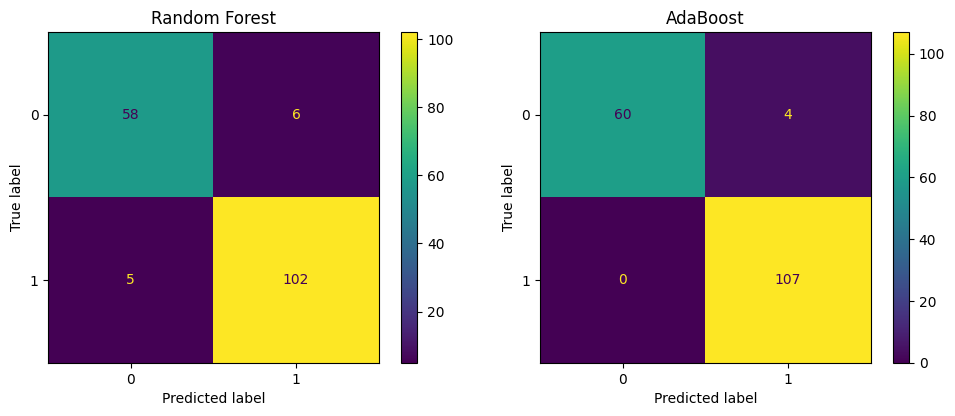

In [13]:
s
# the best bagging-style and boosting-style models make on the real dataset.
best_models = {
    "Random Forest": real_models["Random Forest"],
    "AdaBoost": real_models["AdaBoost"],
}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, (name, model) in zip(axes, best_models.items()):
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)

    ConfusionMatrixDisplay.from_predictions(
        y_test_r,
        y_pred,
        ax=ax
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()